In [1]:
# SIMULAÇÃO: vento solar senoidal (pico em 2020, período de 11 anos, CSV com
# 3 ciclos completos). Compara dois lançamentos -- pico x vale -- cada um
# propagado por 22 anos (2 ciclos solares).

import copy
import json
from datetime import datetime, timedelta
from itertools import combinations

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import RK45
from model.electric_probe import ElectricSailProbe
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from utils.schemas import RequestDto
from services import n_body_service

AU_M = 1.496e11
AU_KM = AU_M / 1000.0
MARS_ORBIT_KM = 1.524 * AU_KM
G_KM = 6.6742e-20

SINE_PERIOD_DAYS = 11 * 365.25  # período do ciclo solar sintético (~11 anos)
MISSION_YEARS = 22               # duração de cada missão (2 ciclos solares)
PHI_DEG = -30.0
THETA_DEG = 0.0


class ScaledWind:
    def __init__(self, frame):
        frame = frame.sort_values(['year', 'doy', 'hour']).reset_index(drop=True)
        self.dates = [
            datetime(int(row.year), 1, 1) + timedelta(
                days=int(row.doy) - 1, hours=int(row.hour)
            )
            for row in frame.itertuples()
        ]
        self.epoch = self.dates[0]
        self.t = np.array([(d - self.epoch).total_seconds() for d in self.dates])
        self.n = frame['dens_cm3'].to_numpy(float) * 1e6
        self.te = frame['temp_k'].to_numpy(float) / 11604.5
        self.v = frame['vel_km_s'].to_numpy(float)

    def _interp(self, values, date):
        x = (date - self.epoch).total_seconds()
        if x < self.t[0] or x > self.t[-1]:
            raise ValueError('Data de vento fora do intervalo: {}'.format(date))
        return float(np.interp(x, self.t, values))

    def at_1au(self, date):
        return self._interp(self.n, date), self._interp(self.te, date), self._interp(self.v, date)

    def at_distance(self, date, radius_m):
        if radius_m <= 0:
            raise ValueError('Distância radial inválida.')
        n1, te1, v = self.at_1au(date)
        scale = AU_M / radius_m
        return n1 * scale**2, te1 * scale**(1.0 / 3.0), v, date


# CSV sintético: pico em 2020-01-01, período de 11 anos, 3 ciclos completos
# (gerado à parte, só para testes -- coloque na mesma pasta do CSV real)
solar_data_corr = pd.read_csv(
    'atividade_solar_senoidal_pico2020.csv', sep=r'\s+', header=None,
    names=['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s'],
    engine='python',
)
wind_corr = ScaledWind(solar_data_corr)


def accel_with_corr_wind(body, date):
    n, te, v, _ = wind_corr.at_distance(date, np.linalg.norm(body.position) * 1000.0)
    old = (
        ElectricSailDynamic._n_earth_m3,
        ElectricSailDynamic._t_e_earth_ev,
        ElectricSailDynamic._v_sw_km_s,
    )
    ElectricSailDynamic._n_earth_m3 = n
    ElectricSailDynamic._t_e_earth_ev = te
    ElectricSailDynamic._v_sw_km_s = v
    try:
        return np.asarray(ElectricSailDynamic.calculate_acceleration(body), dtype=float)
    finally:
        (
            ElectricSailDynamic._n_earth_m3,
            ElectricSailDynamic._t_e_earth_ev,
            ElectricSailDynamic._v_sw_km_s,
        ) = old


def corr_derivatives(t, y, bodies, start_date):
    nbody = len(bodies)
    state = np.asarray(y, dtype=float).reshape(2 * nbody, 3)
    for i, body in enumerate(bodies):
        body.position = state[i].copy()
        body.velocity = state[i + nbody].copy()

    acc = np.zeros((nbody, 3), dtype=float)
    for i, j in combinations(range(nbody), 2):
        d = bodies[j].position - bodies[i].position
        r = np.linalg.norm(d)
        if r < bodies[i].radius + bodies[j].radius:
            raise ArithmeticError(
                'Collision detected between {} and {}'.format(
                    bodies[i].name, bodies[j].name
                )
            )
        acc[i] += G_KM * bodies[j].mass * d / r**3
        acc[j] -= G_KM * bodies[i].mass * d / r**3

    date = start_date + timedelta(seconds=float(t))
    for i, body in enumerate(bodies):
        if isinstance(body, ElectricSailProbe):
            acc[i] += accel_with_corr_wind(body, date)
    return np.concatenate((state[nbody:].ravel(), acc.ravel()))


def solve_corr(bodies, start_date, time_span):
    positions = [np.asarray(b.position, float) for b in bodies]
    velocities = [np.asarray(b.velocity, float) for b in bodies]
    y0 = np.concatenate([np.concatenate(positions), np.concatenate(velocities)])
    rows = [np.insert(y0.copy(), 0, 0.0)]
    rk = RK45(
        lambda t, y: corr_derivatives(t, y, bodies, start_date),
        t0=0.0, y0=y0, t_bound=time_span, max_step=time_span / 1000.0,
        rtol=1e-6, atol=1e-9,
    )
    try:
        while rk.status == 'running':
            rk.step()
            rows.append(np.insert(rk.y.copy(), 0, rk.t))
    except ArithmeticError:
        pass
    return np.asarray(rows, dtype=float)


def corr_columns(nbody):
    columns = ['T']
    for i in range(nbody):
        columns += ['X{}'.format(i), 'Y{}'.format(i), 'Z{}'.format(i)]
    for i in range(nbody):
        columns += ['Vx{}'.format(i), 'Vy{}'.format(i), 'Vz{}'.format(i)]
    return columns


with open('../resources/electric_sail_probe.json', 'r') as f:
    corr_base = json.load(f)

# Datas de lançamento: pico da senoide (2020-01-01) e vale (meio período depois)
PEAK_LAUNCH_DATE = datetime(2020, 1, 1)
TROUGH_LAUNCH_DATE = PEAK_LAUNCH_DATE + timedelta(days=SINE_PERIOD_DAYS / 2.0)
MISSION_DAYS = MISSION_YEARS * 365.25

print('Lançamento no pico: {}'.format(PEAK_LAUNCH_DATE.strftime('%Y-%m-%d')))
print('Lançamento no vale: {}'.format(TROUGH_LAUNCH_DATE.strftime('%Y-%m-%d')))
print(
    'Duração de cada missão: {} anos (~{:.0f} dias, {:.2f} ciclos solares)'.format(
        MISSION_YEARS, MISSION_DAYS, MISSION_YEARS / (SINE_PERIOD_DAYS / 365.25)
    )
)


def run_long_mission(label, launch_date, mission_days, phi_deg, theta_deg, base_config):
    end_date = launch_date + timedelta(days=mission_days)
    config = copy.deepcopy(base_config)
    config['start_time'] = launch_date.strftime('%Y-%m-%d %H:%M:%S')
    config['end_time'] = end_date.strftime('%Y-%m-%d %H:%M:%S')
    config['electric_sail_probes'][0]['phi_deg'] = float(phi_deg)
    config['electric_sail_probes'][0]['theta_deg'] = float(theta_deg)

    bodies, span = n_body_service.process_data(RequestDto().load(config))
    y = solve_corr(bodies, launch_date, span)
    df = pd.DataFrame(y, columns=corr_columns(len(bodies)))

    relative = df[['X1', 'Y1', 'Z1']].to_numpy() - df[['X0', 'Y0', 'Z0']].to_numpy()
    radius_km = np.linalg.norm(relative, axis=1)
    crossings = np.where(radius_km >= MARS_ORBIT_KM)[0]
    cross_idx = int(crossings[0]) if len(crossings) else None
    arrival_days = (
        float(df['T'].iloc[cross_idx] / 86400.0) if cross_idx is not None else None
    )

    return {
        'label': label,
        'launch_date': launch_date,
        'df': df,
        'radius_km': radius_km,
        'arrival_days': arrival_days,
    }


peak_run = run_long_mission(
    'Pico', PEAK_LAUNCH_DATE, MISSION_DAYS, PHI_DEG, THETA_DEG, corr_base
)
trough_run = run_long_mission(
    'Vale', TROUGH_LAUNCH_DATE, MISSION_DAYS, PHI_DEG, THETA_DEG, corr_base
)

print('Simulações concluídas ({} pontos no pico, {} pontos no vale).'.format(
    len(peak_run['df']), len(trough_run['df'])
))


FileNotFoundError: [Errno 2] No such file or directory: 'atividade_solar_senoidal_pico2020.csv'

In [2]:
# COMPARAÇÃO NUMÉRICA (sem gráficos): trajetória pico x vale após 22 anos

import numpy as np
import pandas as pd
from IPython.display import display

required_long = [
    'peak_run', 'trough_run', 'AU_KM', 'SINE_PERIOD_DAYS', 'MISSION_YEARS',
]
missing_long = [name for name in required_long if name not in globals()]
if missing_long:
    raise RuntimeError(
        'Execute primeiro a célula anterior. Variáveis ausentes: {}'.format(
            ', '.join(missing_long)
        )
    )


def heliocentric_distance_at(run, elapsed_days):
    """Distância ao Sol (em UA) no ponto simulado mais próximo de
    elapsed_days após o lançamento."""
    df_run = run['df']
    t_target = elapsed_days * 86400.0
    idx = int(np.searchsorted(df_run['T'].to_numpy(), t_target))
    idx = min(idx, len(df_run) - 1)
    return float(run['radius_km'][idx]) / AU_KM


checkpoints_days = [SINE_PERIOD_DAYS, 2 * SINE_PERIOD_DAYS]
checkpoint_labels = ['dist_1_ciclo_UA', 'dist_2_ciclos_UA']

comparison_rows = []
for run in (peak_run, trough_run):
    row = {
        'cenario': run['label'],
        'data_lancamento': run['launch_date'].strftime('%Y-%m-%d'),
        'chegada_marte_dias': run['arrival_days'],
    }
    for label, days in zip(checkpoint_labels, checkpoints_days):
        row[label] = heliocentric_distance_at(run, days)
    row['dist_final_UA'] = float(run['radius_km'][-1]) / AU_KM
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

diff_final_UA = (trough_run['radius_km'][-1] - peak_run['radius_km'][-1]) / AU_KM
print(
    'Diferença de distância heliocêntrica final (Vale - Pico): {:+.4f} UA'.format(
        diff_final_UA
    )
)

ranking_df = comparison_df[
    ['cenario', 'data_lancamento', 'dist_final_UA']
].sort_values('dist_final_UA', ascending=False).reset_index(drop=True)

print(
    '\nRanking final (mesmo período de missão para os dois: {} anos; '
    'maior distância heliocêntrica ao final primeiro):'.format(MISSION_YEARS)
)
for posicao, row in ranking_df.iterrows():
    print(
        '{}. {} (lançamento {}): {:.4f} UA'.format(
            posicao + 1, row['cenario'], row['data_lancamento'], row['dist_final_UA']
        )
    )


RuntimeError: Execute primeiro a célula anterior. Variáveis ausentes: peak_run, trough_run

In [3]:
# TRAJETÓRIA: lançamento no pico x vale (plano XY heliocêntrico)

import matplotlib.pyplot as plt

required_traj = ['peak_run', 'trough_run', 'MISSION_YEARS']
missing_traj = [name for name in required_traj if name not in globals()]
if missing_traj:
    raise RuntimeError(
        'Execute primeiro as células anteriores. Variáveis ausentes: {}'.format(
            ', '.join(missing_traj)
        )
    )

fig, ax = plt.subplots(figsize=(9, 9))
ax.axis('equal')

trajectory_colors = {'Pico': 'tab:red', 'Vale': 'tab:green'}

for run in (peak_run, trough_run):
    x_rel = run['df']['X1'] - run['df']['X0']
    y_rel = run['df']['Y1'] - run['df']['Y0']
    ax.plot(
        x_rel, y_rel,
        color=trajectory_colors[run['label']],
        label='{} ({})'.format(run['label'], run['launch_date'].strftime('%Y-%m-%d')),
    )

ax.scatter(0, 0, s=150, color='yellow', label='Sol')
ax.set_title(
    'Trajetória heliocêntrica (plano XY): lançamento no pico x vale, {} anos'.format(
        MISSION_YEARS
    )
)
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.grid(True)
ax.legend()
plt.show()


RuntimeError: Execute primeiro as células anteriores. Variáveis ausentes: peak_run, trough_run

In [ ]:
# VENTO SOLAR AO LONGO DE CADA MISSÃO: densidade, temperatura e velocidade
# -- um único gráfico por missão (pico e vale), com as 3 curvas juntas
# (eixos Y triplos, já que as escalas/unidades são bem diferentes).

import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

required_wind_plots = ['peak_run', 'trough_run', 'wind_corr']
missing_wind_plots = [name for name in required_wind_plots if name not in globals()]
if missing_wind_plots:
    raise RuntimeError(
        'Execute primeiro as células anteriores. Variáveis ausentes: {}'.format(
            ', '.join(missing_wind_plots)
        )
    )

# Amostragem: uma missão de 22 anos pode ter dezenas de milhares de pontos
# de integração -- reduzimos para no máximo MAX_POINTS igualmente espaçados,
# suficiente para ver a senoide sem pesar o gráfico.
MAX_POINTS = 3000


def wind_profile(run, max_points=MAX_POINTS):
    df_run = run['df']
    launch_date = run['launch_date']

    n_rows = len(df_run)
    step = max(1, n_rows // max_points)
    sample_idx = np.arange(0, n_rows, step)

    elapsed_days, dens_vals, temp_vals, vel_vals = [], [], [], []
    for idx in sample_idx:
        row = df_run.iloc[idx]
        date = launch_date + timedelta(seconds=float(row['T']))
        relative = np.array([
            row['X1'] - row['X0'], row['Y1'] - row['Y0'], row['Z1'] - row['Z0'],
        ])
        radius_m = float(np.linalg.norm(relative)) * 1000.0
        n, te, v, _ = wind_corr.at_distance(date, radius_m)

        elapsed_days.append(row['T'] / 86400.0)
        dens_vals.append(n / 1e6)   # m^-3 -> cm^-3 (mesma unidade do CSV)
        temp_vals.append(te)        # eV
        vel_vals.append(v)          # km/s

    return {
        'elapsed_days': np.array(elapsed_days),
        'density_cm3': np.array(dens_vals),
        'temperature_eV': np.array(temp_vals),
        'speed_km_s': np.array(vel_vals),
    }


def plot_wind_triple(run, profile):
    color_dens, color_temp, color_vel = 'tab:blue', 'tab:orange', 'tab:green'

    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.15))

    l1, = ax1.plot(
        profile['elapsed_days'], profile['density_cm3'],
        color=color_dens, label='Densidade (cm⁻³)',
    )
    l2, = ax2.plot(
        profile['elapsed_days'], profile['temperature_eV'],
        color=color_temp, label='Temperatura (eV)',
    )
    l3, = ax3.plot(
        profile['elapsed_days'], profile['speed_km_s'],
        color=color_vel, label='Velocidade (km/s)',
    )

    ax1.set_xlabel('Tempo desde o lançamento (dias)')
    ax1.set_ylabel('Densidade (cm⁻³)', color=color_dens)
    ax2.set_ylabel('Temperatura (eV)', color=color_temp)
    ax3.set_ylabel('Velocidade (km/s)', color=color_vel)

    ax1.tick_params(axis='y', colors=color_dens)
    ax2.tick_params(axis='y', colors=color_temp)
    ax3.tick_params(axis='y', colors=color_vel)

    ax1.set_title(
        'Vento solar ao longo da missão -- {} (lançamento {})'.format(
            run['label'], run['launch_date'].strftime('%Y-%m-%d')
        )
    )
    lines = [l1, l2, l3]
    ax1.legend(lines, [line.get_label() for line in lines], loc='upper right')
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


peak_wind_profile = wind_profile(peak_run)
trough_wind_profile = wind_profile(trough_run)

plot_wind_triple(peak_run, peak_wind_profile)
plot_wind_triple(trough_run, trough_wind_profile)


Intervalo da tabela: 1963-11-28 a 2026-08-31
Linhas inválidas substituídas/interpoladas: {'temp_k': 3889, 'dens_cm3': 3325, 'vel_km_s': 2602}


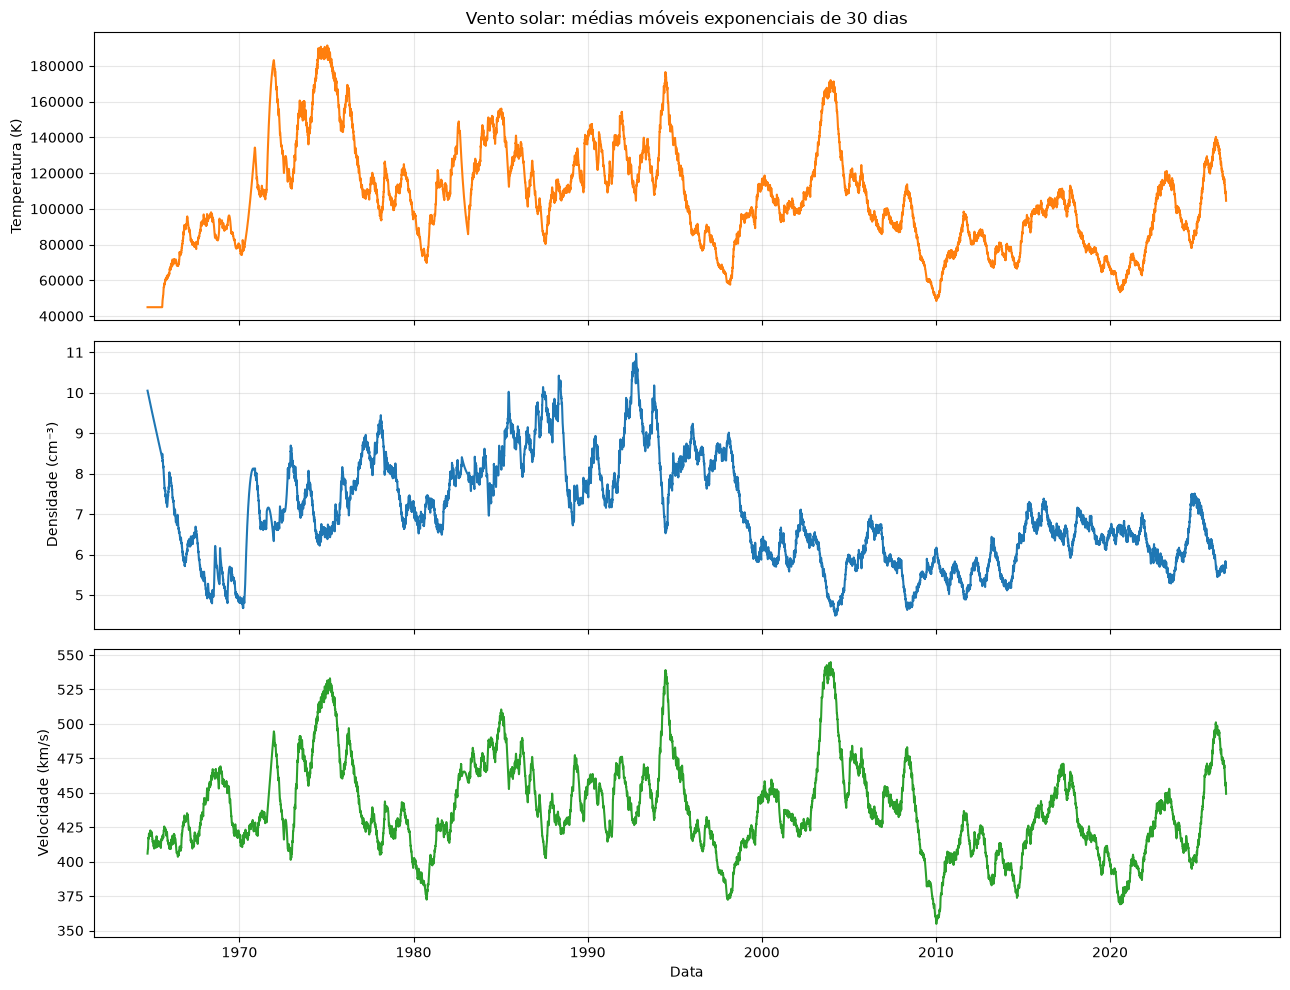

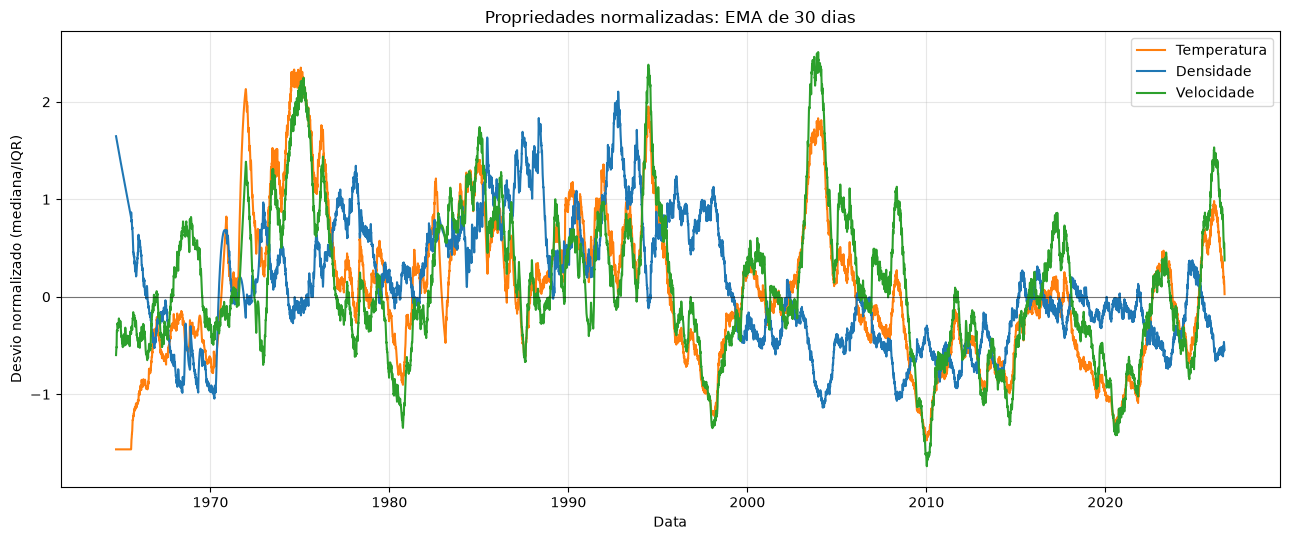

In [9]:
# DIAGNÓSTICO: médias móveis exponenciais de 30 dias
# Esta célula é independente das quatro células anteriores.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EMA_DAYS = 300
SOLAR_CSV = 'atividade_solar.csv'

solar_activity_df = pd.read_csv(
    SOLAR_CSV,
    sep=r'\s+',
    header=None,
    names=['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s'],
    engine='python',
)

solar_activity_df['date'] = (
    pd.to_datetime(
        solar_activity_df['year'].astype(int).astype(str) + '-01-01'
    )
    + pd.to_timedelta(solar_activity_df['doy'].astype(int) - 1, unit='D')
    + pd.to_timedelta(solar_activity_df['hour'].astype(float), unit='h')
)
solar_activity_df = (
    solar_activity_df.sort_values('date')
    .drop_duplicates('date', keep='first')
    .set_index('date')
)

# Valores fora destes limites são tratados como códigos de preenchimento
# ou medidas inválidas; eles não podem criar falsos picos na EMA.
valid_limits = {
    'temp_k': (0.0, 1.0e6),
    'dens_cm3': (0.0, 100.0),
    'vel_km_s': (200.0, 1000.0),
}
invalid_counts = {}
for column, (lower, upper) in valid_limits.items():
    values = pd.to_numeric(solar_activity_df[column], errors='coerce')
    invalid = (~np.isfinite(values)) | (values <= lower) | (values >= upper)
    invalid_counts[column] = int(invalid.sum())
    solar_activity_df.loc[invalid, column] = np.nan

# Interpolação temporal apenas para preencher lacunas inválidas antes da EMA.
for column in valid_limits:
    solar_activity_df[column] = (
        solar_activity_df[column]
        .interpolate(method='time', limit_direction='both')
    )

ema_30d_df = pd.DataFrame(index=solar_activity_df.index)
for column in valid_limits:
    ema_30d_df[column + '_ema30d'] = (
        solar_activity_df[column]
        .ewm(span=EMA_DAYS, adjust=False, min_periods=EMA_DAYS)
        .mean()
    )

# Padronização robusta: mediana = 0 e intervalo interquartil = 1.
# Isso permite comparar as três grandezas sem misturar suas unidades.
ema_30d_normalized_df = pd.DataFrame(index=ema_30d_df.index)
for column in valid_limits:
    ema_column = column + '_ema30d'
    values = ema_30d_df[ema_column]
    center = values.median()
    scale = values.quantile(0.75) - values.quantile(0.25)
    if not np.isfinite(scale) or scale == 0:
        scale = values.std()
    ema_30d_normalized_df[ema_column] = (values - center) / scale

print('Intervalo da tabela: {} a {}'.format(
    solar_activity_df.index.min().strftime('%Y-%m-%d'),
    solar_activity_df.index.max().strftime('%Y-%m-%d'),
))
print('Linhas inválidas substituídas/interpoladas: {}'.format(invalid_counts))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
physical_specs = [
    ('temp_k_ema30d', 'Temperatura (K)', 'tab:orange'),
    ('dens_cm3_ema30d', 'Densidade (cm⁻³)', 'tab:blue'),
    ('vel_km_s_ema30d', 'Velocidade (km/s)', 'tab:green'),
]
for axis, (column, ylabel, color) in zip(axes, physical_specs):
    axis.plot(ema_30d_df.index, ema_30d_df[column], color=color)
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
axes[0].set_title('Vento solar: médias móveis exponenciais de 30 dias')
axes[-1].set_xlabel('Data')
fig.tight_layout()
plt.show()
plt.close(fig)

fig, axis = plt.subplots(figsize=(13, 5.5))
normalized_specs = [
    ('temp_k_ema30d', 'Temperatura', 'tab:orange'),
    ('dens_cm3_ema30d', 'Densidade', 'tab:blue'),
    ('vel_km_s_ema30d', 'Velocidade', 'tab:green'),
]
for column, label, color in normalized_specs:
    axis.plot(
        ema_30d_normalized_df.index,
        ema_30d_normalized_df[column],
        color=color,
        label=label,
    )
axis.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axis.set_title(
    'Propriedades normalizadas: EMA de 30 dias'
)
axis.set_xlabel('Data')
axis.set_ylabel('Desvio normalizado (mediana/IQR)')
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


In [10]:
# perfil direto x perfil invertido
import copy
import json
from datetime import datetime, timedelta
from itertools import combinations

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import RK45
from model.electric_probe import ElectricSailProbe
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from utils.schemas import RequestDto
from services import n_body_service

required_profile_data = ['solar_activity_df']
missing_profile_data = [
    name for name in required_profile_data if name not in globals()
]
if missing_profile_data:
    raise RuntimeError(
        'Execute primeiro a célula 5. Variáveis ausentes: {}'.format(
            ', '.join(missing_profile_data)
        )
    )

VALLEY_DATE = '2009-01-10'       
PEAK_DATE = '2003-01-10'         
PHI_REAL_DEG = -30.0
THETA_REAL_DEG = 0.0
MAX_STEP_DAYS_REAL = 1.0

if VALLEY_DATE is None or PEAK_DATE is None:
    raise ValueError(
        'Preencha VALLEY_DATE e PEAK_DATE no formato YYYY-MM-DD.'
    )

valley_requested = pd.Timestamp(VALLEY_DATE)
peak_requested = pd.Timestamp(PEAK_DATE)

def nearest_table_date(requested_date, available_dates):
    distances = np.abs(
        available_dates.to_numpy(dtype='datetime64[ns]')
        - requested_date.to_datetime64()
    )
    return pd.Timestamp(available_dates[np.argmin(distances)])

valley_date = nearest_table_date(
    valley_requested, solar_activity_df.index
)
peak_date = nearest_table_date(
    peak_requested, solar_activity_df.index
)
profile_start = min(valley_date, peak_date)
profile_end = max(valley_date, peak_date)

profile_frame = solar_activity_df.loc[profile_start:profile_end].copy()
if len(profile_frame) < 2:
    raise ValueError(
        'A janela escolhida precisa conter pelo menos dois registros.'
    )

if valley_date < peak_date:
    forward_label = 'Vale → Pico'
    reverse_label = 'Pico → Vale'
else:
    forward_label = 'Pico → Vale'
    reverse_label = 'Vale → Pico'

print(
    'Data de vale solicitada/selecionada: {} / {}'.format(
        valley_requested.strftime('%Y-%m-%d'),
        valley_date.strftime('%Y-%m-%d'),
    )
)
print(
    'Data de pico solicitada/selecionada: {} / {}'.format(
        peak_requested.strftime('%Y-%m-%d'),
        peak_date.strftime('%Y-%m-%d'),
    )
)
print(
    'Janela utilizada: {} a {} ({} registros)'.format(
        profile_start.strftime('%Y-%m-%d'),
        profile_end.strftime('%Y-%m-%d'),
        len(profile_frame),
    )
)

AU_M_REAL = 1.496e11
AU_KM_REAL = AU_M_REAL / 1000.0
MARS_ORBIT_KM_REAL = 1.524 * AU_KM_REAL
G_KM_REAL = 6.6742e-20


class ProfileWind:
    """Perfil temporal sem atraso de propagação, direto ou invertido."""

    def __init__(self, frame, reverse=False):
        frame = frame.sort_index()
        if reverse:
            frame = frame.iloc[::-1]

        self.reverse = reverse
        self.source_dates = pd.DatetimeIndex(frame.index)
        first_date = self.source_dates[0]
        if reverse:
            self.times = np.array([
                (first_date - date).total_seconds()
                for date in self.source_dates
            ])
        else:
            self.times = np.array([
                (date - first_date).total_seconds()
                for date in self.source_dates
            ])

        self.n = frame['dens_cm3'].to_numpy(float) * 1e6
        self.te = frame['temp_k'].to_numpy(float) / 11604.5
        self.v = frame['vel_km_s'].to_numpy(float)

    def at_elapsed(self, elapsed_seconds):
        elapsed = float(np.clip(
            elapsed_seconds, self.times[0], self.times[-1]
        ))
        n = float(np.interp(elapsed, self.times, self.n))
        te = float(np.interp(elapsed, self.times, self.te))
        v = float(np.interp(elapsed, self.times, self.v))
        return n, te, v

    def at_distance(self, elapsed_seconds, radius_m):
        if radius_m <= 0:
            raise ValueError('Distância radial inválida.')
        n1, te1, v = self.at_elapsed(elapsed_seconds)
        scale = AU_M_REAL / radius_m
        return n1 * scale**2, te1 * scale**(1.0 / 3.0), v


def accel_with_profile_wind(body, elapsed_seconds, wind_profile):
    n, te, v = wind_profile.at_distance(
        elapsed_seconds, np.linalg.norm(body.position) * 1000.0
    )
    old = (
        ElectricSailDynamic._n_earth_m3,
        ElectricSailDynamic._t_e_earth_ev,
        ElectricSailDynamic._v_sw_km_s,
    )
    ElectricSailDynamic._n_earth_m3 = n
    ElectricSailDynamic._t_e_earth_ev = te
    ElectricSailDynamic._v_sw_km_s = v
    try:
        return np.asarray(
            ElectricSailDynamic.calculate_acceleration(body),
            dtype=float,
        )
    finally:
        (
            ElectricSailDynamic._n_earth_m3,
            ElectricSailDynamic._t_e_earth_ev,
            ElectricSailDynamic._v_sw_km_s,
        ) = old


def profile_derivatives(t, y, bodies, wind_profile):
    nbody = len(bodies)
    state = np.asarray(y, dtype=float).reshape(2 * nbody, 3)

    for i, body in enumerate(bodies):
        body.position = state[i].copy()
        body.velocity = state[i + nbody].copy()

    acc = np.zeros((nbody, 3), dtype=float)
    for i, j in combinations(range(nbody), 2):
        displacement = bodies[j].position - bodies[i].position
        distance = np.linalg.norm(displacement)
        if distance < bodies[i].radius + bodies[j].radius:
            raise ArithmeticError(
                'Collision detected between {} and {}'.format(
                    bodies[i].name, bodies[j].name
                )
            )
        acc[i] += G_KM_REAL * bodies[j].mass * displacement / distance**3
        acc[j] -= G_KM_REAL * bodies[i].mass * displacement / distance**3

    for i, body in enumerate(bodies):
        if isinstance(body, ElectricSailProbe):
            acc[i] += accel_with_profile_wind(
                body, t, wind_profile
            )

    return np.concatenate((state[nbody:].ravel(), acc.ravel()))


def solve_profile(bodies, wind_profile, time_span):
    positions = [np.asarray(body.position, float) for body in bodies]
    velocities = [np.asarray(body.velocity, float) for body in bodies]
    y0 = np.concatenate([
        np.concatenate(positions),
        np.concatenate(velocities),
    ])
    rows = [np.insert(y0.copy(), 0, 0.0)]
    max_step = min(
        time_span / 1000.0,
        MAX_STEP_DAYS_REAL * 86400.0,
    )
    rk = RK45(
        lambda t, y: profile_derivatives(
            t, y, bodies, wind_profile
        ),
        t0=0.0,
        y0=y0,
        t_bound=time_span,
        max_step=max_step,
        rtol=1e-6,
        atol=1e-9,
    )
    try:
        while rk.status == 'running':
            rk.step()
            rows.append(np.insert(rk.y.copy(), 0, rk.t))
    except ArithmeticError:
        pass
    return np.asarray(rows, dtype=float)


def profile_columns(nbody):
    columns = ['T']
    for i in range(nbody):
        columns += ['X{}'.format(i), 'Y{}'.format(i), 'Z{}'.format(i)]
    for i in range(nbody):
        columns += ['Vx{}'.format(i), 'Vy{}'.format(i), 'Vz{}'.format(i)]
    return columns


with open('../resources/electric_sail_probe.json', 'r') as config_file:
    real_base_config = json.load(config_file)

profile_time_span = (
    profile_end - profile_start
).total_seconds()
profile_wind_forward = ProfileWind(profile_frame, reverse=False)
profile_wind_reverse = ProfileWind(profile_frame, reverse=True)


def run_profile(label, wind_profile):
    config = copy.deepcopy(real_base_config)
    config['start_time'] = profile_start.strftime('%Y-%m-%d %H:%M:%S')
    config['end_time'] = profile_end.strftime('%Y-%m-%d %H:%M:%S')
    config['electric_sail_probes'][0]['phi_deg'] = float(PHI_REAL_DEG)
    config['electric_sail_probes'][0]['theta_deg'] = float(THETA_REAL_DEG)

    bodies, span = n_body_service.process_data(
        RequestDto().load(config)
    )
    y = solve_profile(bodies, wind_profile, span)
    df = pd.DataFrame(
        y, columns=profile_columns(len(bodies))
    )

    relative = df[['X1', 'Y1', 'Z1']].to_numpy() - df[
        ['X0', 'Y0', 'Z0']
    ].to_numpy()
    radius_km = np.linalg.norm(relative, axis=1)
    crossings = np.where(radius_km >= MARS_ORBIT_KM_REAL)[0]
    cross_idx = int(crossings[0]) if len(crossings) else None
    arrival_days = (
        float(df['T'].iloc[cross_idx] / 86400.0)
        if cross_idx is not None else None
    )

    return {
        'label': label,
        'df': df,
        'radius_km': radius_km,
        'arrival_days': arrival_days,
        'wind_profile': wind_profile,
        'config': config,
    }


forward_run = run_profile(forward_label, profile_wind_forward)
reverse_run = run_profile(reverse_label, profile_wind_reverse)

print(
    'Simulações concluídas: {} ({} pontos) e {} ({} pontos).'.format(
        forward_run['label'],
        len(forward_run['df']),
        reverse_run['label'],
        len(reverse_run['df']),
    )
)


Data de vale solicitada/selecionada: 2009-01-10 / 2009-01-10
Data de pico solicitada/selecionada: 2003-01-10 / 2003-01-10
Janela utilizada: 2003-01-10 a 2009-01-10 (2193 registros)
Simulações concluídas: Pico → Vale (2243 pontos) e Vale → Pico (2248 pontos).


In [11]:
# comparando numericamente os perfis
import numpy as np
import pandas as pd
from IPython.display import display

required_runs_real = ['forward_run', 'reverse_run', 'profile_start', 'profile_end']
missing_runs_real = [
    name for name in required_runs_real if name not in globals()
]
if missing_runs_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_runs_real)
        )
    )

mission_days_real = (
    profile_end - profile_start
).total_seconds() / 86400.0
checkpoint_fractions_real = [0.5, 1.0]


def distance_at_elapsed(run, elapsed_days):
    target = float(elapsed_days) * 86400.0
    times = run['df']['T'].to_numpy(dtype=float)
    idx = int(np.searchsorted(times, target))
    idx = min(idx, len(times) - 1)
    return float(run['radius_km'][idx]) / AU_KM_REAL


comparison_rows_real = []
for run in (forward_run, reverse_run):
    row = {
        'cenario': run['label'],
        'tempo_chegada_marte_dias': run['arrival_days'],
    }
    for fraction in checkpoint_fractions_real:
        days = mission_days_real * fraction
        row['dist_{:.0f}_porcento_UA'.format(fraction * 100)] = (
            distance_at_elapsed(run, days)
        )
    row['dist_final_UA'] = (
        float(run['radius_km'][-1]) / AU_KM_REAL
    )
    comparison_rows_real.append(row)

comparison_real_df = pd.DataFrame(comparison_rows_real)
display(comparison_real_df)

diff_final_real = (
    reverse_run['radius_km'][-1] - forward_run['radius_km'][-1]
) / AU_KM_REAL
print(
    'Diferença de distância final (invertido - direto): '
    '{:+.4f} UA'.format(diff_final_real)
)

diff_arrival_real = None
if (
    forward_run['arrival_days'] is not None
    and reverse_run['arrival_days'] is not None
):
    diff_arrival_real = (
        reverse_run['arrival_days'] - forward_run['arrival_days']
    )
    print(
        'Diferença de tempo de chegada (invertido - direto): '
        '{:+.4f} dias'.format(diff_arrival_real)
    )

ranking_real_df = comparison_real_df.sort_values(
    'dist_final_UA',
    ascending=False,
).reset_index(drop=True)

print('Ranking final pela distância heliocêntrica:')
for position, row in ranking_real_df.iterrows():
    print(
        '{}. {}: {:.4f} UA'.format(
            position + 1,
            row['cenario'],
            row['dist_final_UA'],
        )
    )


,cenario,tempo_chegada_marte_dias,dist_50_porcento_UA,dist_100_porcento_UA,dist_final_UA
0,Pico → Vale,174.572335,2.455796,3.109813,3.109813
1,Vale → Pico,245.826605,1.931845,2.154193,2.154193


Diferença de distância final (invertido - direto): -0.9556 UA
Diferença de tempo de chegada (invertido - direto): +71.2543 dias
Ranking final pela distância heliocêntrica:
1. Pico → Vale: 3.1098 UA
2. Vale → Pico: 2.1542 UA


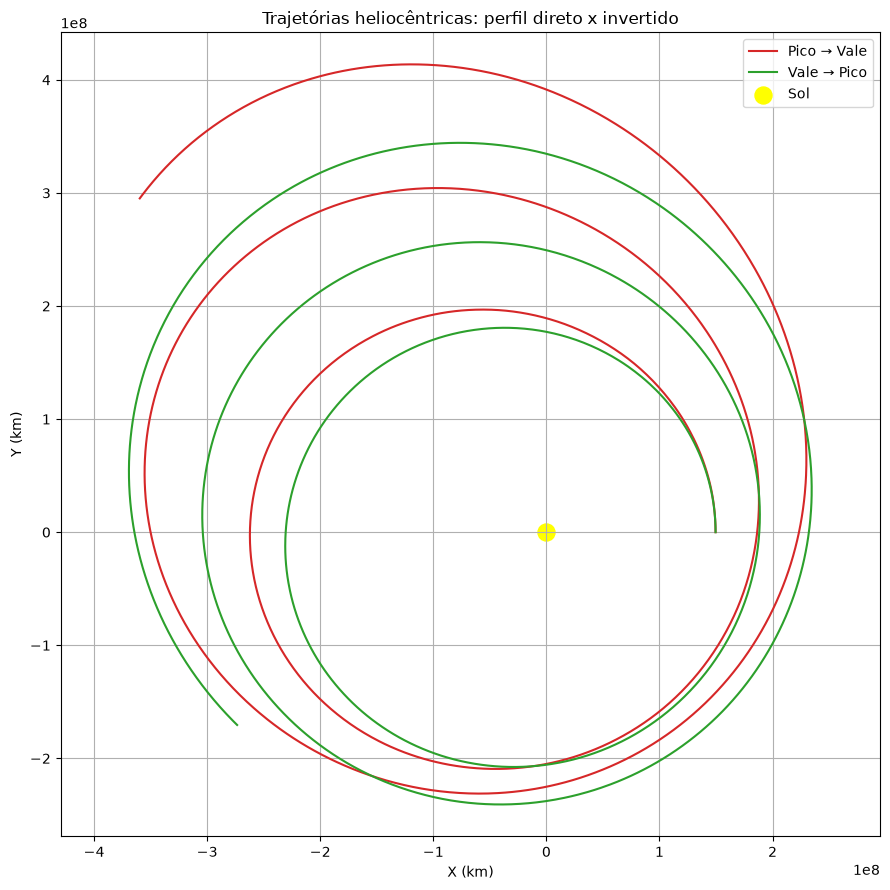

In [12]:
# comparando trajetorias

import matplotlib.pyplot as plt

required_traj_real = ['forward_run', 'reverse_run']
missing_traj_real = [
    name for name in required_traj_real if name not in globals()
]
if missing_traj_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_traj_real)
        )
    )

trajectory_colors_real = {
    forward_run['label']: 'tab:red',
    reverse_run['label']: 'tab:green',
}

fig, ax = plt.subplots(figsize=(9, 9))
ax.axis('equal')

for run in (forward_run, reverse_run):
    x_relative = run['df']['X1'] - run['df']['X0']
    y_relative = run['df']['Y1'] - run['df']['Y0']
    ax.plot(
        x_relative,
        y_relative,
        color=trajectory_colors_real[run['label']],
        label=run['label'],
    )

ax.scatter(0, 0, s=150, color='yellow', label='Sol')
ax.set_title(
    'Trajetórias heliocêntricas: perfil direto x invertido'
)
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


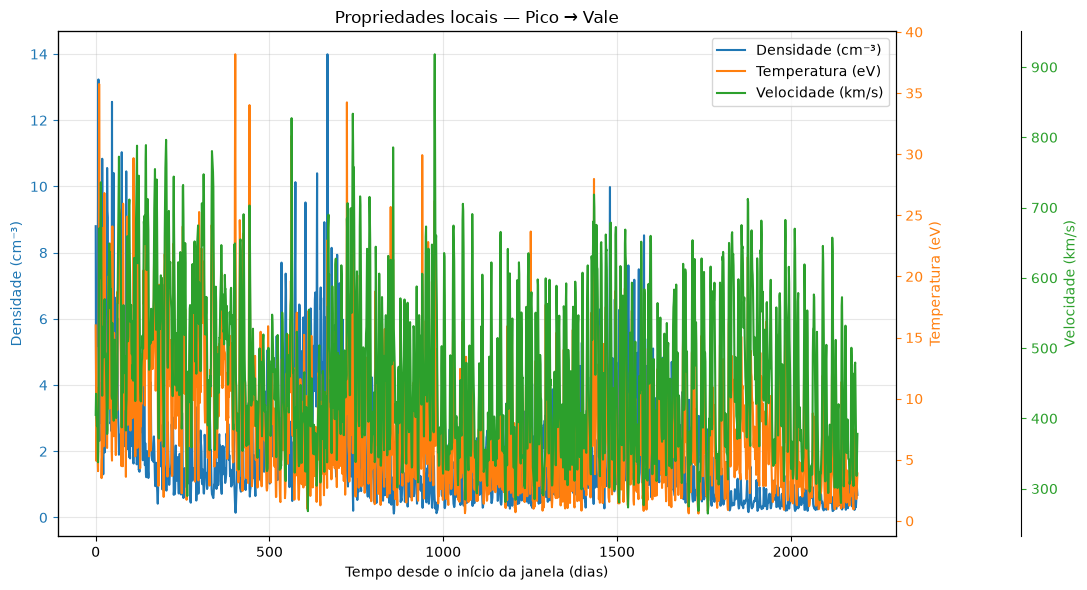

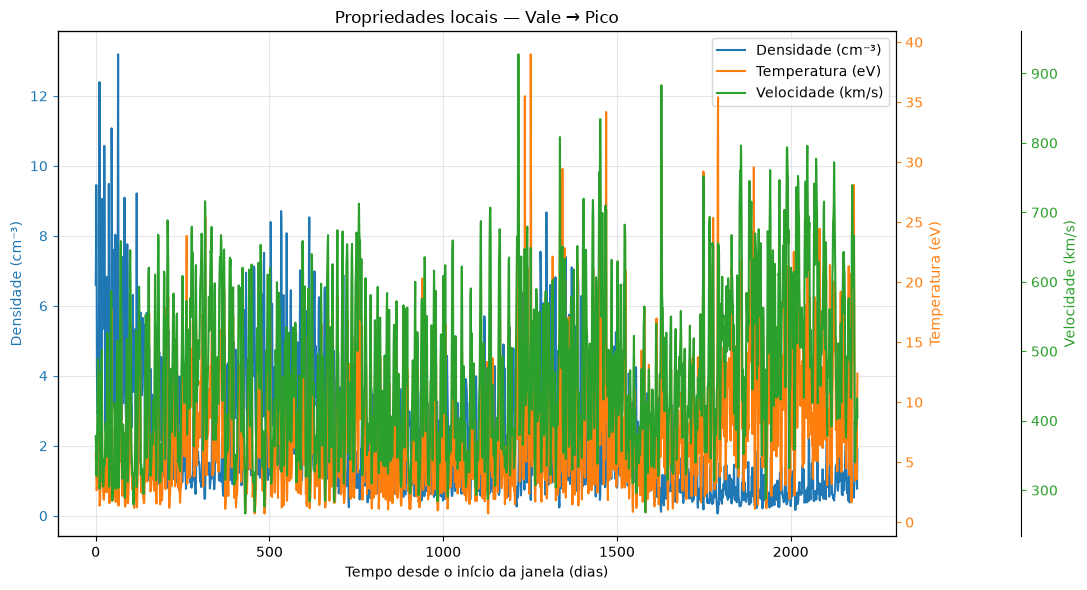

In [13]:
# comparando as propriedades

import numpy as np
import matplotlib.pyplot as plt

required_wind_real = [
    'forward_run', 'reverse_run', 'profile_wind_forward',
    'profile_wind_reverse',
]
missing_wind_real = [
    name for name in required_wind_real if name not in globals()
]
if missing_wind_real:
    raise RuntimeError(
        'Execute primeiro a célula 6. Variáveis ausentes: {}'.format(
            ', '.join(missing_wind_real)
        )
    )

MAX_PROFILE_POINTS_REAL = 3000


def local_wind_profile_real(run, max_points=MAX_PROFILE_POINTS_REAL):
    df_run = run['df']
    n_rows = len(df_run)
    step = max(1, n_rows // max_points)
    sample_indices = np.arange(0, n_rows, step)

    elapsed_days = []
    density_cm3 = []
    temperature_eV = []
    speed_km_s = []

    for index in sample_indices:
        row = df_run.iloc[index]
        elapsed_seconds = float(row['T'])
        relative = np.array([
            row['X1'] - row['X0'],
            row['Y1'] - row['Y0'],
            row['Z1'] - row['Z0'],
        ])
        radius_m = float(np.linalg.norm(relative)) * 1000.0
        n, te, v = run['wind_profile'].at_distance(
            elapsed_seconds, radius_m
        )

        elapsed_days.append(elapsed_seconds / 86400.0)
        density_cm3.append(n / 1e6)
        temperature_eV.append(te)
        speed_km_s.append(v)

    return {
        'elapsed_days': np.asarray(elapsed_days),
        'density_cm3': np.asarray(density_cm3),
        'temperature_eV': np.asarray(temperature_eV),
        'speed_km_s': np.asarray(speed_km_s),
    }


def plot_wind_triple_real(run, profile):
    color_density = 'tab:blue'
    color_temperature = 'tab:orange'
    color_speed = 'tab:green'

    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.15))

    line1, = ax1.plot(
        profile['elapsed_days'],
        profile['density_cm3'],
        color=color_density,
        label='Densidade (cm⁻³)',
    )
    line2, = ax2.plot(
        profile['elapsed_days'],
        profile['temperature_eV'],
        color=color_temperature,
        label='Temperatura (eV)',
    )
    line3, = ax3.plot(
        profile['elapsed_days'],
        profile['speed_km_s'],
        color=color_speed,
        label='Velocidade (km/s)',
    )

    ax1.set_xlabel('Tempo desde o início da janela (dias)')
    ax1.set_ylabel('Densidade (cm⁻³)', color=color_density)
    ax2.set_ylabel('Temperatura (eV)', color=color_temperature)
    ax3.set_ylabel('Velocidade (km/s)', color=color_speed)
    ax1.tick_params(axis='y', colors=color_density)
    ax2.tick_params(axis='y', colors=color_temperature)
    ax3.tick_params(axis='y', colors=color_speed)
    ax1.set_title(
        'Propriedades locais — {}'.format(run['label'])
    )
    ax1.legend(
        [line1, line2, line3],
        [line1.get_label(), line2.get_label(), line3.get_label()],
        loc='upper right',
    )
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


forward_profile_real = local_wind_profile_real(forward_run)
reverse_profile_real = local_wind_profile_real(reverse_run)

plot_wind_triple_real(forward_run, forward_profile_real)
plot_wind_triple_real(reverse_run, reverse_profile_real)
